# Water-level Imputation v2 — with NDVI

This is a revised version of the original ML imputation notebook with four changes:

1. **NDVI added as a predictor** (level-12 HydroBASINS, monthly mean)
2. **`runoff` dropped from features** — it leaked information about the target
3. **ERA5 fallback** when observed climate is missing (better than mean-imputing)
4. **Time-aware train/validation split kept** (no shuffling)

Inputs:
- `master_dataset_inputed.csv` — your existing imputed master file
- `ndvi_per_river.xlsx` — per-river NDVI from Earth Engine (HydroBASINS level 12)

Output: water-level columns filled in by the best model per river, plus a summary table.


## 1. Setup and load data

In [15]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- File paths (edit these if needed) ---
MASTER_PATH = '../data/outputs/master_dataset_inputed.csv'   # existing monthly master dataset
NDVI_PATH   = './ndvi.xlsx'
OUTPUT_PATH = '../data/outputs/master_dataset_inputed.csv'   # overwrite in place


In [17]:
master = pd.read_csv(MASTER_PATH)
master['date'] = pd.to_datetime(master['date'])
print(f"Master dataset: {len(master)} rows, {master['river'].nunique()} rivers")
print(f"Date range: {master['date'].min().date()} to {master['date'].max().date()}")
master.head()


Master dataset: 4664 rows, 10 rivers
Date range: 1981-01-01 to 2024-12-01


,river,date,year,month,water_level,runoff,temp_max_observed,temp_min_observed,precip_observed,temp_source,...,era5_v10_mean,era5_d2m_mean,era5_msl_mean,temp_max_imputed,temp_min_imputed,precip_bias_factor,precip_imputed,ndvi,water_level_imputed_v2,wl_imputed_v2
0,Buzimba,1981-01-01,1981,1,0.541000,16.94,26.619355,17.38424,154.966725,NYANZA LAC (IRAT),...,0.862369,17.834026,101288.167581,False,True,0.255013,True,NaN,0.541000,False
1,Buzimba,1981-02-01,1981,2,0.485000,15.35,26.696429,17.38900,120.119005,NYANZA LAC (IRAT),...,0.571162,17.862381,101189.626012,False,True,0.255013,True,NaN,0.485000,False
2,Buzimba,1981-03-01,1981,3,0.548387,17.96,26.087097,18.16450,126.911998,NYANZA LAC (IRAT),...,0.580950,17.995201,101215.039026,False,True,0.255013,True,NaN,0.548387,False
3,Buzimba,1981-04-01,1981,4,0.648000,13.90,26.093333,18.14420,117.792010,NYANZA LAC (IRAT),...,0.503440,18.345753,101272.027799,False,True,0.255013,True,NaN,0.648000,False
4,Buzimba,1981-05-01,1981,5,0.594194,10.83,25.896774,17.22097,117.313940,NYANZA LAC (IRAT),...,0.361469,17.841975,101381.430497,False,True,0.255013,True,NaN,0.594194,False


## 2. Load NDVI and aggregate to monthly

NDVI comes at MODIS 16-day cadence (~2 values per month). We average those to get
one NDVI value per river per month, then merge on `river + year + month`.

In [ ]:
ndvi = pd.read_excel(NDVI_PATH)
ndvi['date'] = pd.to_datetime(ndvi['date'])
ndvi['year'] = ndvi['date'].dt.year
ndvi['month'] = ndvi['date'].dt.month

ndvi_monthly = (ndvi.groupby(['river', 'year', 'month'], as_index=False)['NDVI_mean']
                    .mean()
                    .rename(columns={'NDVI_mean': 'ndvi'}))

print(f"NDVI monthly rows: {len(ndvi_monthly)}")
print(f"NDVI date range: {ndvi['date'].min().date()} to {ndvi['date'].max().date()}")
ndvi_monthly.head()


NDVI monthly rows: 2870
NDVI date range: 2000-02-18 to 2023-12-19


,river,year,month,ndvi
0,Buzimba,2000,2,0.712440
1,Buzimba,2000,3,0.392762
2,Buzimba,2000,4,0.369540
3,Buzimba,2000,5,0.558034
4,Buzimba,2000,6,0.439063


In [ ]:
# Don't add ndvi twice if the notebook is rerun
if 'ndvi' in master.columns:
    master = master.drop(columns=['ndvi'])

df = master.merge(ndvi_monthly, on=['river', 'year', 'month'], how='left')
print(f"Merged rows: {len(df)}  (should equal master: {len(master)})")
print(f"NDVI populated: {df['ndvi'].notna().sum()}  | missing (pre-2000): {df['ndvi'].isna().sum()}")


Merged rows: 4664  (should equal master: 4664)
NDVI populated: 2632  | missing (pre-2000): 2032


## 3. Build the feature columns

For each predictor we prefer the **observed** climate value; if it's missing we fall
back to the corresponding **ERA5** column. This is more honest than the previous
notebook, which filled missing predictor values with the column mean
(which destroys seasonality).

In [ ]:
# Use observed where available, otherwise ERA5
df['temp_max'] = df['temp_max_observed'].fillna(df['era5_t2m_max'])
df['temp_min'] = df['temp_min_observed'].fillna(df['era5_t2m_min'])
df['precip']   = df['precip_observed'].fillna(df['era5_tp_sum'])

FEATURES = ['temp_max', 'temp_min', 'precip', 'ndvi']
TARGET = 'water_level'

print("Feature completeness:")
print(df[FEATURES].notna().sum())


Feature completeness:
temp_max    4664
temp_min    4664
precip      4664
ndvi        2632
dtype: int64


## 4. Train 4 models per river and pick the best

Same 4 models as before: Linear, Ridge, Lasso, RandomForest.
For each river we:
- Train on rows where `water_level` is known **and** all features (incl. NDVI) are present
- Validate on the most recent 20% of those rows (time-aware split)
- Score with RMSE and MAE
- Pick the model with the lowest RMSE as the **best model** for that river

NDVI restricts training to **2000 onwards** (where NDVI exists). That's fine
because all rivers have plenty of post-2000 data.

In [ ]:
models = {
    'Linear':       LinearRegression(),
    'Ridge':        Ridge(alpha=1.0),
    'Lasso':        Lasso(alpha=0.01, max_iter=10000),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

results = []
for river in sorted(df['river'].unique()):
    river_df = df[df['river'] == river].sort_values('date').copy()
    train_df = river_df.dropna(subset=[TARGET] + FEATURES)
    if len(train_df) < 30:
        print(f"  {river}: skipped (only {len(train_df)} usable rows)")
        continue

    X = train_df[FEATURES].values
    y = train_df[TARGET].values
    X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, shuffle=False)

    for name, m in models.items():
        m.fit(X_tr, y_tr)
        preds = m.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, preds))
        mae  = mean_absolute_error(y_va, preds)
        results.append({'river': river, 'model': name, 'rmse': rmse,
                        'mae': mae, 'n_train': len(train_df)})

results_df = pd.DataFrame(results)
print("\n=== Full results ===")
print(results_df.round(3).to_string(index=False))



=== Full results ===
     river        model  rmse   mae  n_train
   Buzimba       Linear 0.711 0.654      132
   Buzimba        Ridge 0.715 0.658      132
   Buzimba        Lasso 0.717 0.661      132
   Buzimba RandomForest 0.836 0.752      132
      Jiji       Linear 0.150 0.120      287
      Jiji        Ridge 0.147 0.117      287
      Jiji        Lasso 0.161 0.133      287
      Jiji RandomForest 0.137 0.103      287
Kaburantwa       Linear 0.494 0.453      175
Kaburantwa        Ridge 0.495 0.453      175
Kaburantwa        Lasso 0.494 0.453      175
Kaburantwa RandomForest 0.501 0.453      175
    Mpanda       Linear 0.270 0.252      161
    Mpanda        Ridge 0.263 0.246      161
    Mpanda        Lasso 0.264 0.247      161
    Mpanda RandomForest 0.271 0.249      161
  Mulembwe       Linear 0.723 0.673      247
  Mulembwe        Ridge 0.713 0.662      247
  Mulembwe        Lasso 0.697 0.642      247
  Mulembwe RandomForest 0.703 0.637      247
 Mutimbuzi       Linear 0.436 0.3

In [ ]:
best = results_df.loc[results_df.groupby('river')['rmse'].idxmin()]
best = best.rename(columns={'model': 'best_model'}).sort_values('river').reset_index(drop=True)
print("=== Best model per river ===")
print(best[['river', 'best_model', 'rmse', 'mae', 'n_train']].round(3).to_string(index=False))

print("\n=== Average RMSE per model across rivers ===")
print(results_df.groupby('model')['rmse'].mean().round(3).sort_values().to_string())


=== Best model per river ===
     river   best_model  rmse   mae  n_train
   Buzimba       Linear 0.711 0.654      132
      Jiji RandomForest 0.137 0.103      287
Kaburantwa        Lasso 0.494 0.453      175
    Mpanda        Ridge 0.263 0.246      161
  Mulembwe        Lasso 0.697 0.642      247
 Mutimbuzi       Linear 0.436 0.370      102
Nyakagunda RandomForest 0.071 0.062      129
 Nyamagana RandomForest 0.543 0.528      161
   Nyengwe       Linear 0.244 0.215      137
    Rusizi RandomForest 0.916 0.854      181

=== Average RMSE per model across rivers ===
model
Linear          0.468
Ridge           0.480
Lasso           0.487
RandomForest    0.487


## 5. Impute missing water levels

For each river:
- Refit the river's best model on all available training rows (no validation split — we want maximum info)
- Predict for rows where `water_level` is missing **and** all features (including NDVI) exist
- Write predictions into a new column `water_level_imputed_v2`
- Add a flag column `wl_imputed_v2` (True for imputed rows, False for observed)

Rows where NDVI is missing (pre-2000) **stay missing** — we don't impute outside NDVI coverage.

In [ ]:
df['water_level_imputed_v2'] = df[TARGET]
df['wl_imputed_v2'] = False

best_map = dict(zip(best['river'], best['best_model']))

for river, model_name in best_map.items():
    river_df = df[df['river'] == river].copy()
    train = river_df.dropna(subset=[TARGET] + FEATURES)
    # rows we CAN impute: water_level missing AND all features present
    to_impute = river_df[river_df[TARGET].isna() & river_df[FEATURES].notna().all(axis=1)]
    if len(train) < 30 or len(to_impute) == 0:
        continue

    model = {'Linear': LinearRegression(),
             'Ridge': Ridge(alpha=1.0),
             'Lasso': Lasso(alpha=0.01, max_iter=10000),
             'RandomForest': RandomForestRegressor(
                 n_estimators=200, random_state=42, n_jobs=-1)}[model_name]
    model.fit(train[FEATURES].values, train[TARGET].values)
    preds = model.predict(to_impute[FEATURES].values)
    df.loc[to_impute.index, 'water_level_imputed_v2'] = preds
    df.loc[to_impute.index, 'wl_imputed_v2'] = True

print("Imputation summary:")
print(df.groupby('river').agg(
    observed=('water_level', 'count'),
    imputed_v2=('wl_imputed_v2', 'sum'),
    still_missing=('water_level_imputed_v2', lambda x: x.isna().sum()),
))


Imputation summary:
            observed  imputed_v2  still_missing
river                                          
Buzimba          344          35             17
Jiji             523           0              5
Kaburantwa       339         112             58
Mpanda           171          20              0
Mulembwe         475          40              6
Mutimbuzi        130         185            116
Nyakagunda       300         158             70
Nyamagana        336         126             66
Nyengwe          252         138            114
Rusizi           361         106             61


## 6. Diagnostic plots

One plot per river showing the observed water level (dashed) vs the v2 imputation.

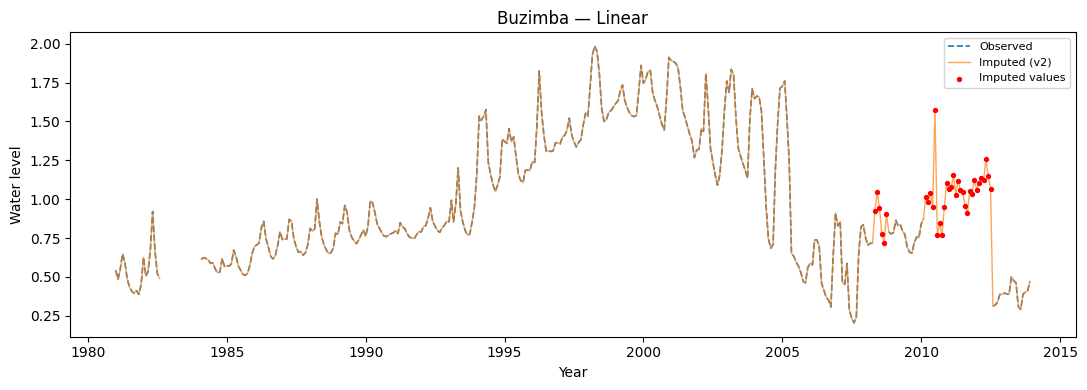

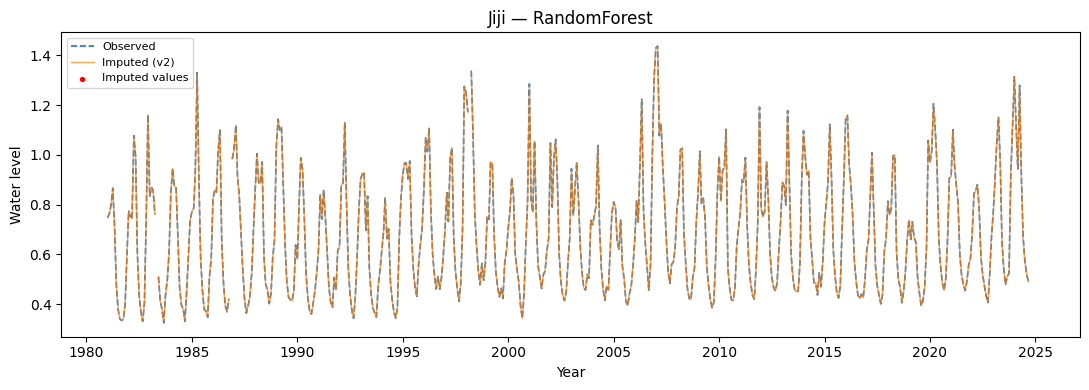

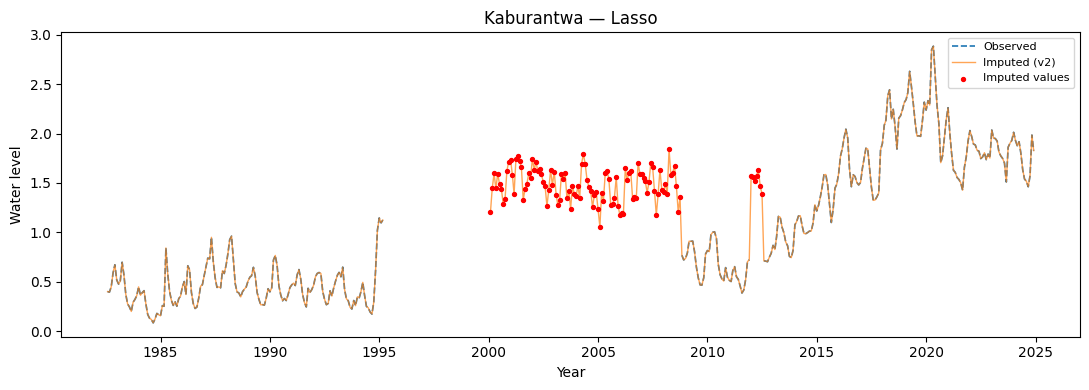

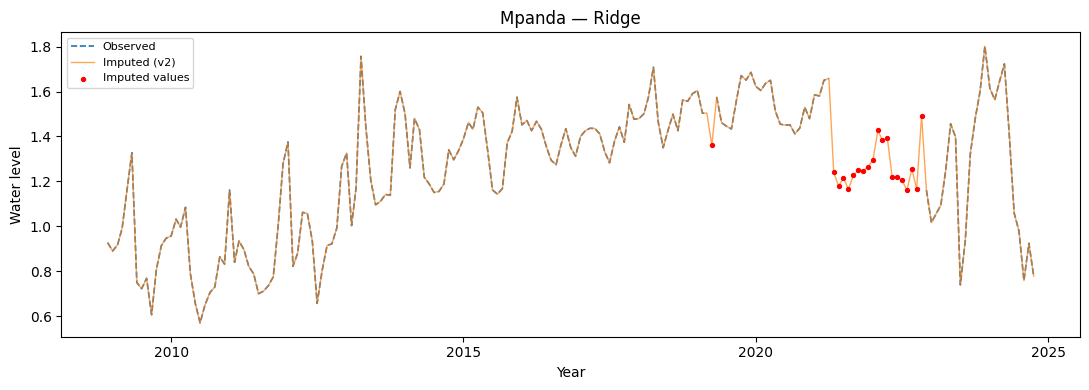

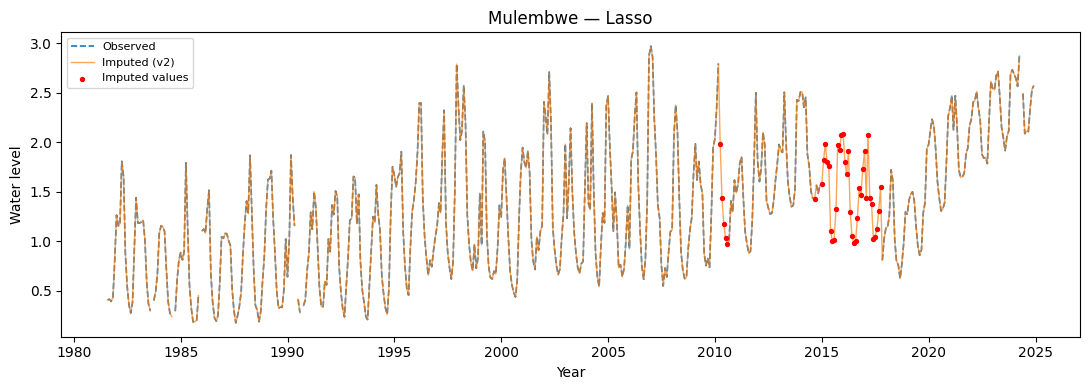

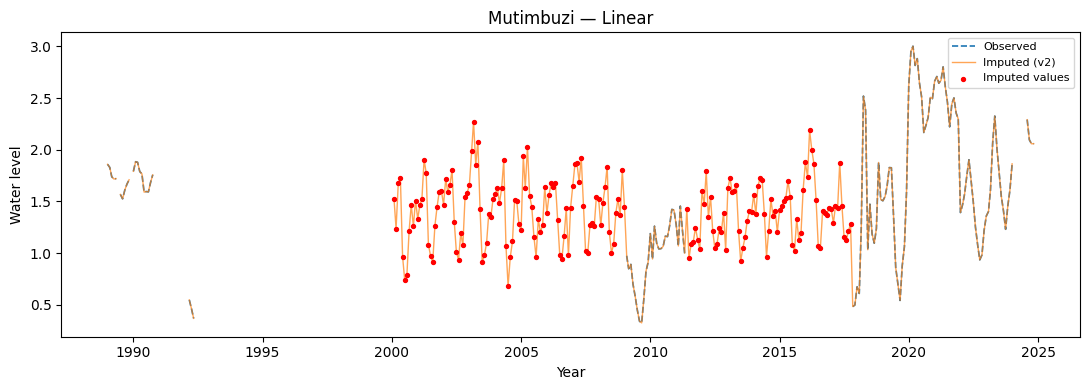

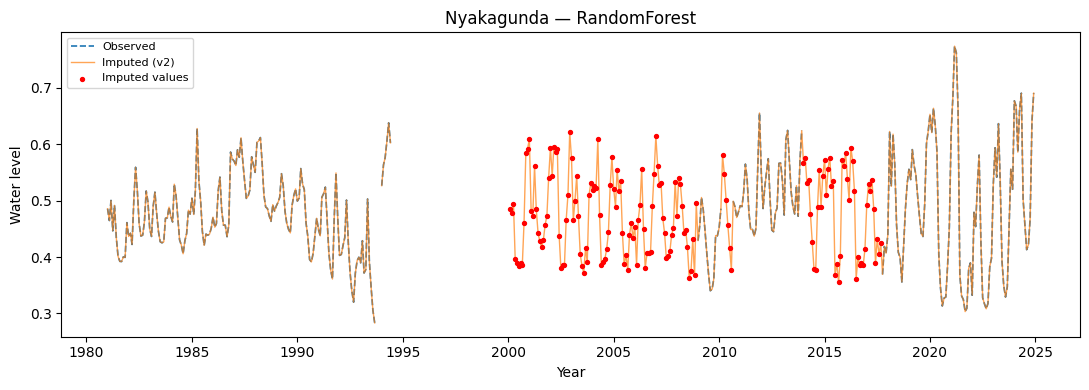

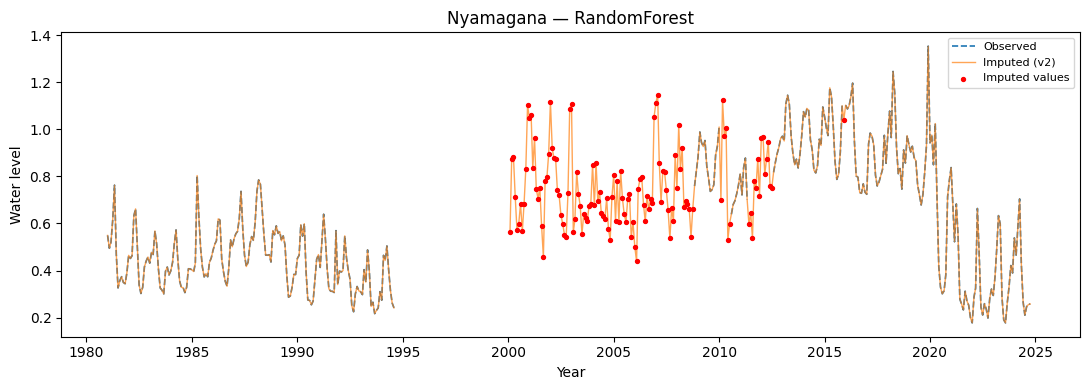

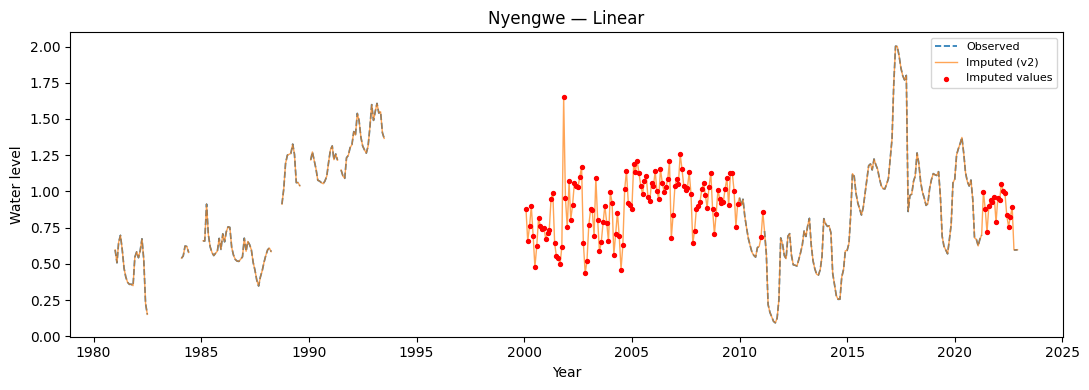

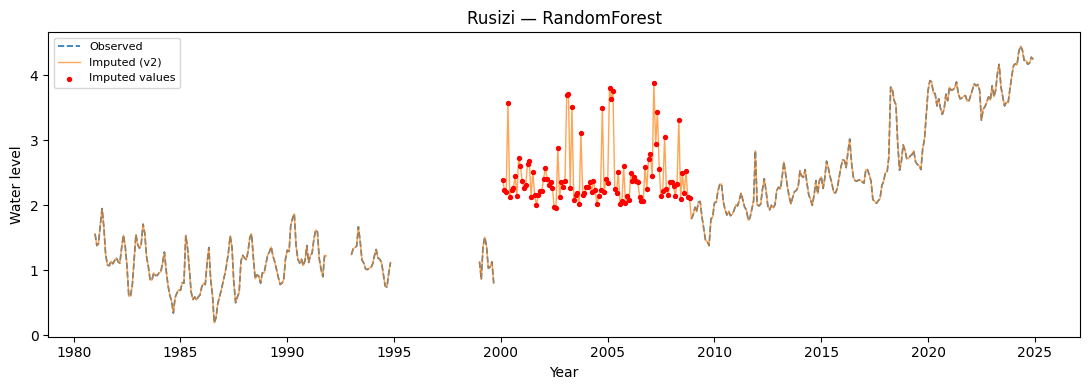

In [ ]:
for river in sorted(df['river'].unique()):
    rdf = df[df['river'] == river].sort_values('date')
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(rdf['date'], rdf['water_level'], linestyle='--',
            label='Observed', linewidth=1.2)
    ax.plot(rdf['date'], rdf['water_level_imputed_v2'],
            label='Imputed (v2)', alpha=0.7, linewidth=1)
    # mark imputed points in red so they stand out
    imp = rdf[rdf['wl_imputed_v2']]
    ax.scatter(imp['date'], imp['water_level_imputed_v2'],
               s=8, color='red', label='Imputed values', zorder=3)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_title(f"{river} — {best_map.get(river, 'n/a')}")
    ax.set_xlabel('Year')
    ax.set_ylabel('Water level')
    ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()


## 7. Save back to the master dataset

Overwrites `master_dataset_inputed.csv` in place. **Back the file up first** if you
haven't already — copy it to `master_dataset_inputed.csv.bak` outside this notebook.

In [ ]:
# Keep only the new columns when writing back
keep = list(master.columns) + ['ndvi', 'water_level_imputed_v2', 'wl_imputed_v2']
out = df[[c for c in keep if c in df.columns]].copy()
out.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to {OUTPUT_PATH}")
print(f"Shape: {out.shape}")
print(f"New columns: ndvi, water_level_imputed_v2, wl_imputed_v2")


Saved to ../data/outputs/master_dataset_inputed.csv
Shape: (4664, 27)
New columns: ndvi, water_level_imputed_v2, wl_imputed_v2


## 8. (Optional) Try lagged NDVI

Rivers respond to vegetation with a delay — last month's NDVI may matter more
than this month's. This cell tests whether adding `ndvi_lag1`, `ndvi_lag2`, `ndvi_lag3`
as extra features improves RMSE. Run it only if you want to explore further; it
does **not** save anything.

In [ ]:
lag_df = df.sort_values(['river', 'date']).copy()
for L in (1, 2, 3):
    lag_df[f'ndvi_lag{L}'] = lag_df.groupby('river')['ndvi'].shift(L)

LAG_FEATURES = ['temp_max', 'temp_min', 'precip', 'ndvi',
                'ndvi_lag1', 'ndvi_lag2', 'ndvi_lag3']

lag_results = []
for river in sorted(lag_df['river'].unique()):
    rdf = lag_df[lag_df['river'] == river].dropna(subset=[TARGET] + LAG_FEATURES)
    if len(rdf) < 30:
        continue
    X = rdf[LAG_FEATURES].values
    y = rdf[TARGET].values
    X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, shuffle=False)

    # use the same best model as before for a fair comparison
    name = best_map.get(river, 'Lasso')
    m = {'Linear': LinearRegression(),
         'Ridge': Ridge(alpha=1.0),
         'Lasso': Lasso(alpha=0.01, max_iter=10000),
         'RandomForest': RandomForestRegressor(
             n_estimators=200, random_state=42, n_jobs=-1)}[name]
    m.fit(X_tr, y_tr)
    rmse = np.sqrt(mean_squared_error(y_va, m.predict(X_va)))
    lag_results.append({'river': river, 'model': name, 'rmse_with_lags': rmse})

lag_df_res = pd.DataFrame(lag_results).set_index('river')
compare = best.set_index('river')[['best_model', 'rmse']].rename(
    columns={'rmse': 'rmse_no_lags'})
compare = compare.join(lag_df_res[['rmse_with_lags']])
compare['lag_improvement_%'] = (
    100 * (compare['rmse_no_lags'] - compare['rmse_with_lags']) / compare['rmse_no_lags']
).round(1)
print("=== Effect of adding lagged NDVI ===")
print(compare.round(3))
print(f"\nAverage RMSE: no lags = {compare['rmse_no_lags'].mean():.3f},"
      f"  with lags = {compare['rmse_with_lags'].mean():.3f}")


=== Effect of adding lagged NDVI ===
              best_model  rmse_no_lags  rmse_with_lags  lag_improvement_%
river                                                                    
Buzimba           Linear         0.711           0.725               -1.8
Jiji        RandomForest         0.137           0.147               -7.8
Kaburantwa         Lasso         0.494           0.494                0.0
Mpanda             Ridge         0.263           0.246                6.5
Mulembwe           Lasso         0.697           0.703               -0.9
Mutimbuzi         Linear         0.436           0.421                3.5
Nyakagunda  RandomForest         0.071           0.063               11.2
Nyamagana   RandomForest         0.543           0.545               -0.5
Nyengwe           Linear         0.244           0.240                1.8
Rusizi      RandomForest         0.916           0.889                3.0

Average RMSE: no lags = 0.451,  with lags = 0.447


## Notes

- NDVI restricts training and imputation to **2000 onwards**. Pre-2000 water-level
  gaps are *not* imputed by this notebook — they would need a model that doesn't
  use NDVI as a required feature.
- `runoff` was dropped from features because it carries information about
  `water_level` directly (both measure river flow), which inflates apparent
  model accuracy.
- All splits are time-aware (`shuffle=False`), so validation always covers the
  most recent 20% — a realistic test of how the model performs on new data.
